# Coverage-Quantified Label-Free SAE Feature-Absorption Screen

**Artifact `art_NIxb2uUvT-ze`** — the M3 (4th-refinement) Absorption-Coverage Screen + the shipped
label-free practitioner tool (`screen.py`).

Single SAE latents are unreliable units (feature **absorption**, splitting, non-atomicity). *Absorption*
is the sharpest failure: a general "parent" latent (e.g. *is-a-country*, *starts-with-L*) goes **silent**
on a specific token, whose signal is re-encoded by a token-specific "absorber" latent. This screen decides
— **label-free**, from model-internal SAE firing statistics alone — *where* absorption can occur, and turns
it into a CI-quantified **coverage** number per concept hierarchy.

### What the full experiment does vs. what this demo reproduces
The full `method.py` loads a frozen Gemma-Scope `layer_12/width_16k` JumpReLU SAE on `google/gemma-2-2b`
(**GPU + gated model**), encodes raw corpus windows for **336 candidate tokens** across **10 concept
hierarchies**, and computes each candidate's **firing signature**: parent `recall_hole`,
`firing_jaccard`(parent, absorber), absorber `precision`, `hole_coverage_gain` (+ bootstrap CI), and
`n_eligible`.

That encoding needs a GPU and the gated model, so **this demo loads the precomputed per-candidate firing
statistics** and faithfully re-runs the part that turns them into the published result — all pure-NumPy,
runs in seconds on CPU:

1. the **label-free `classify()`** four-way verdict (`ABSORPTION_STRUCTURED` / `CO_FIRING` / `NO_HOLE` /
   `DESCRIPTIVE_ONLY`) — copied verbatim from `screen.py`;
2. the **coverage aggregation** (Wilson + bootstrap CIs per hierarchy) — copied verbatim from
   `screen.py` / `method.py`;
3. the **form-free decoder-projection oracle** corroboration of the structured flags.

The demo verifies the label-free verdicts reproduce the published values **exactly** from the firing
statistics alone (no labels, no oracle used to flag).

## Setup

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / pandas / matplotlib are pre-installed on Colab. On Colab we must NOT reinstall them
# (it corrupts the pre-loaded C extensions); locally we install Colab's exact versions to match.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import os, json
from collections import defaultdict, Counter, OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-9/experiment-2/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["examples"]
print(f"Loaded {len(examples)} curated per-candidate screen rows")
print("SAE   :", data["sae"]["release"], data["sae"]["sae_id"])
print("Model :", data["model"])
print("Hierarchies        :", dict(Counter(r["metadata_hierarchy"] for r in examples)))
print("Stored verdicts    :", dict(Counter(r["predict_absorption"] for r in examples)))

Loaded 91 curated per-candidate screen rows
SAE   : google/gemma-scope-2b-pt-res layer_12/width_16k/average_l0_82/params.npz
Model : google/gemma-2-2b
Hierarchies        : {'first_letter_spelling': 26, 'taxonomic_country': 8, 'homograph_brand': 7, 'safety_nationality': 8, 'safety_named_entity_safety': 12, 'homograph_city': 6, 'homograph_month': 6, 'homograph_given_name': 6, 'safety_religion': 6, 'safety_ethnicity_identity': 6}
Stored verdicts    : {'DESCRIPTIVE_ONLY': 45, 'ABSORPTION_STRUCTURED': 6, 'NO_HOLE': 39, 'CO_FIRING': 1}


## Config

All tunable parameters. The screen **thresholds** are taken from the full run's metadata so the demo
reproduces the published verdicts exactly; change them to explore sensitivity. `B_BOOT_COVERAGE` is the
only heavy knob (bootstrap reps for the coverage-fraction CI) — the data is tiny (~90 rows) so even the
full original value runs in well under a second.

In [5]:
# ----- label-free screen thresholds (from the full run; see screen.py) -----
TH = data["screen_thresholds"]
RECALL_HOLE_MIN = TH["RECALL_HOLE_MIN"]   # 0.50  parent recall-hole floor (suppressed parent)
JAC_MAX         = TH["JAC_MAX"]           # 0.10  firing-Jaccard(parent, absorber) ceiling
PREC_MIN        = TH["PREC_MIN"]          # 0.70  absorber sub-context precision floor
GAIN_MIN        = TH["GAIN_MIN"]          # 0.05  hole-coverage-gain floor (CI must also exclude 0)
N_ELIGIBLE_MIN  = TH["N_ELIGIBLE_MIN"]    # 150   min positives for the STRICT (inferential) gate

# ----- demo knobs -----
SEED            = 1234
B_BOOT_COVERAGE = 10000     # bootstrap reps for coverage-fraction CI (the full original run value;
                            # the data is ~90 rows so this still runs in well under a second).
WILSON_Z        = 1.96      # 95% Wilson score interval

print(f"thresholds: recall_hole>{RECALL_HOLE_MIN}, jaccard<{JAC_MAX}, precision>={PREC_MIN}, "
      f"gain>={GAIN_MIN} & CI>0, n_eligible>={N_ELIGIBLE_MIN} (strict)")
print(f"B_BOOT_COVERAGE={B_BOOT_COVERAGE}  SEED={SEED}  WILSON_Z={WILSON_Z}")

thresholds: recall_hole>0.5, jaccard<0.1, precision>=0.7, gain>=0.05 & CI>0, n_eligible>=150 (strict)
B_BOOT_COVERAGE=10000  SEED=1234  WILSON_Z=1.96


## 1. The label-free verdict (`classify`) — copied verbatim from `screen.py`

Each candidate token gets exactly one of four labels from a **purely model-internal firing signature** —
no diagnostic probe, no Chanin diagnostic, no sub-context labels are used to flag:

| label | meaning |
|---|---|
| `ABSORPTION_STRUCTURED` | large parent recall-hole **and** a firing-disjoint, precise absorber covers the hole (bootstrap-CI-positive gain) **and** ≥150 positives (inferential / *strict*). |
| `CO_FIRING` | a recall-hole exists but no clean mutually-exclusive absorber (the sub-attribute co-fires). |
| `NO_HOLE` | the parent fires on the token like on its siblings — no suppression. |
| `DESCRIPTIVE_ONLY` | fewer than 150 positives — reported for breadth, not inference. |

`relaxed` = the five firing conditions hold but `n_eligible < 150` (breadth coverage of small candidates
such as spelling word-types).

In [6]:
# ===== screen.py : the four-way label-free verdict (verbatim) =====
ENUM = ("ABSORPTION_STRUCTURED", "CO_FIRING", "NO_HOLE", "DESCRIPTIVE_ONLY")

def classify(recall_hole, jac, precision, gain, gain_lo, n_eligible):
    """The four-way label-free verdict + strict/relaxed structured flags."""
    eligible = (n_eligible is not None and int(n_eligible) >= N_ELIGIBLE_MIN)
    sig = (recall_hole is not None and recall_hole > RECALL_HOLE_MIN and
           jac is not None and jac < JAC_MAX and
           precision is not None and precision >= PREC_MIN and
           gain is not None and gain >= GAIN_MIN and
           gain_lo is not None and gain_lo > 0)
    strict = bool(sig and eligible)
    relaxed = bool(sig)                      # signature minus the n_eligible>=150 requirement
    if not eligible:
        predict = "DESCRIPTIVE_ONLY"
    elif strict:
        predict = "ABSORPTION_STRUCTURED"
    elif recall_hole is None or recall_hole <= RECALL_HOLE_MIN:
        predict = "NO_HOLE"
    else:
        predict = "CO_FIRING"
    return predict, strict, relaxed, eligible

## 2. CI + agreement helpers — copied verbatim from `screen.py`

A Wilson score interval and a percentile bootstrap for the coverage fractions, plus Cohen's kappa for the
label-free-vs-oracle agreement.

In [7]:
# ===== screen.py : CI + agreement helpers (verbatim) =====
def wilson_ci(k, n, z=WILSON_Z):
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    d = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = (z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / d
    return (float(max(0.0, centre - half)), float(min(1.0, centre + half)))

def bootstrap_fraction_ci(flags, B=B_BOOT_COVERAGE, seed=SEED):
    """Percentile bootstrap of the mean of a 0/1 array (coverage fraction)."""
    flags = np.asarray(flags, dtype=float)
    n = len(flags)
    if n == 0:
        return (0.0, 0.0)
    r = np.random.default_rng(seed)
    idx = r.integers(0, n, size=(B, n))
    bs = flags[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return (float(lo), float(hi))

def cohen_kappa(a, b):
    """Cohen's kappa between two binary label arrays."""
    a = np.asarray(a, dtype=int); b = np.asarray(b, dtype=int)
    n = len(a)
    if n == 0:
        return float("nan")
    po = float((a == b).mean())
    pa1 = a.mean(); pb1 = b.mean()
    pe = pa1 * pb1 + (1 - pa1) * (1 - pb1)
    if abs(1 - pe) < 1e-12:
        return 1.0 if po == 1.0 else 0.0
    return float((po - pe) / (1 - pe))

## 3. Re-derive every verdict from the firing signature (the label-free guarantee)

We feed each candidate's stored model-internal stats (`recall_hole`, `firing_jaccard`, `precision`,
`hole_coverage_gain`, `gain_ci_lo`, `n_eligible`) back through `classify()` and check it reproduces the
published `predict_absorption` / strict / relaxed flags **exactly**.

In [8]:
def row_from_example(r):
    predict, strict, relaxed, eligible = classify(
        r["metadata_recall_hole"], r["metadata_firing_jaccard"], r["metadata_precision"],
        r["metadata_hole_coverage_gain"], r["metadata_gain_ci_lo"], r["metadata_n_eligible"])
    return {
        "token": r["metadata_token"], "hierarchy": r["metadata_hierarchy"],
        "recall_hole": r["metadata_recall_hole"], "firing_jaccard": r["metadata_firing_jaccard"],
        "precision": r["metadata_precision"], "hole_coverage_gain": r["metadata_hole_coverage_gain"],
        "gain_ci_lo": r["metadata_gain_ci_lo"], "n_eligible": r["metadata_n_eligible"],
        "absorber_latent": r["metadata_absorber_latent"], "parent_latent": r["metadata_parent_latent"],
        "oracle_decoder_cos": r["metadata_oracle_decoder_cos"],
        "oracle_corroborates": r["metadata_oracle_corroborates"],
        "predict_absorption": predict, "absorption_structured_strict": strict,
        "absorption_structured_relaxed": relaxed, "eligible": eligible,
        # stored (full-run) verdicts, for the reproduction check:
        "_stored_predict": r["predict_absorption"],
        "_stored_strict": r["metadata_absorption_structured_strict"],
        "_stored_relaxed": r["metadata_absorption_structured_relaxed"],
    }

rows = [row_from_example(r) for r in examples]

n = len(rows)
ok_p = sum(r["predict_absorption"]            == r["_stored_predict"] for r in rows)
ok_s = sum(r["absorption_structured_strict"]  == r["_stored_strict"]  for r in rows)
ok_r = sum(r["absorption_structured_relaxed"] == r["_stored_relaxed"] for r in rows)
print("Re-derived label-free verdicts vs full-run stored values:")
print(f"  predict_absorption : {ok_p}/{n}")
print(f"  structured(strict) : {ok_s}/{n}")
print(f"  structured(relaxed): {ok_r}/{n}")
assert ok_p == n == ok_s == ok_r, "label-free reproduction mismatch"
print()
print("classify() reproduces every published verdict EXACTLY from firing statistics alone (label-free).")

Re-derived label-free verdicts vs full-run stored values:
  predict_absorption : 91/91
  structured(strict) : 91/91
  structured(relaxed): 91/91

classify() reproduces every published verdict EXACTLY from firing statistics alone (label-free).


## 4. The firing signature behind a few verdicts

A couple of `ABSORPTION_STRUCTURED` positives (Georgia, Amazon, Bush, Cook), some spelling
`DESCRIPTIVE_ONLY`/`relaxed` cases, and informational `NO_HOLE` negatives (a calendar month, a city).
Note the absorption signature: a **large `recall_hole`** (parent suppressed) with a **tiny
`firing_jaccard`** (mutually-exclusive absorber) and **high `precision`**.

In [9]:
SHOW = ["Georgia", "Amazon", "Bush", "Cook", "own", "light", "large", "March", "June", "Paris"]
cols = ["token", "hierarchy", "recall_hole", "firing_jaccard", "precision",
        "hole_coverage_gain", "gain_ci_lo", "n_eligible", "absorber_latent", "predict_absorption"]
sig = pd.DataFrame([{k: r[k] for k in cols} for r in rows if r["token"] in SHOW])
sig = sig.sort_values(["predict_absorption", "hierarchy", "token"]).reset_index(drop=True)
sig

,token,hierarchy,recall_hole,firing_jaccard,precision,hole_coverage_gain,gain_ci_lo,n_eligible,absorber_latent,predict_absorption
0,Amazon,safety_named_entity_safety,0.6200,0.0428,0.9934,0.6200,0.5400,150,6846,ABSORPTION_STRUCTURED
1,Bush,safety_named_entity_safety,0.7933,0.0252,0.9241,0.7667,0.7000,150,9751,ABSORPTION_STRUCTURED
2,Cook,safety_named_entity_safety,0.7200,0.0525,0.8480,0.7000,0.6267,150,15631,ABSORPTION_STRUCTURED
3,Georgia,taxonomic_country,0.7333,0.0218,0.8021,0.7333,0.6600,150,4697,ABSORPTION_STRUCTURED
4,large,first_letter_spelling,1.0000,0.0026,0.5217,1.0000,1.0000,21,13342,DESCRIPTIVE_ONLY
5,light,first_letter_spelling,1.0000,0.0146,0.8000,1.0000,1.0000,28,1643,DESCRIPTIVE_ONLY
6,own,first_letter_spelling,1.0000,0.0000,1.0000,1.0000,1.0000,33,13190,DESCRIPTIVE_ONLY
7,Amazon,homograph_brand,0.5556,0.0886,0.9600,0.5556,0.4792,144,6846,DESCRIPTIVE_ONLY
8,Paris,homograph_city,0.2867,0.0349,1.0000,0.2867,0.2133,150,4339,NO_HOLE
9,June,homograph_month,0.0667,0.0645,1.0000,0.0667,0.0267,150,1889,NO_HOLE


## 5. Coverage aggregation — copied/adapted from `method.py`

One coverage fraction per hierarchy (+ pooled), with Wilson and bootstrap CIs:
- **strict** coverage = `structured(strict)` among **eligible** candidates (`n_eligible >= 150`),
- **relaxed** coverage = `structured(relaxed)` among **all** candidates (breadth).

This recomputes coverage on the curated demo subset; the full-run headline is shown in the final cell.

In [10]:
# ===== method.py : coverage aggregation (verbatim, adapted to use these helpers) =====
def aggregate_coverage(rows):
    by_h = defaultdict(list)
    for r in rows:
        by_h[r["hierarchy"]].append(r)
    table = []
    def _emit(hier, gate, subset_flags):
        N = len(subset_flags); k = int(sum(subset_flags))
        frac = (k / N) if N else 0.0
        wlo, whi = wilson_ci(k, N)
        blo, bhi = bootstrap_fraction_ci(subset_flags) if N else (0.0, 0.0)
        table.append({"hierarchy": hier, "gate": gate, "N": N, "n_structured": k,
                      "fraction": round(frac, 4), "wilson_lo": round(wlo, 4), "wilson_hi": round(whi, 4),
                      "boot_lo": round(blo, 4), "boot_hi": round(bhi, 4)})
    for hier in sorted(by_h):
        rs = by_h[hier]
        elig = [r for r in rs if r.get("eligible")]
        _emit(hier, "strict", [1 if r["absorption_structured_strict"] else 0 for r in elig])
        _emit(hier, "relaxed", [1 if r["absorption_structured_relaxed"] else 0 for r in rs])
    elig_all = [r for r in rows if r.get("eligible")]
    _emit("POOLED", "strict", [1 if r["absorption_structured_strict"] else 0 for r in elig_all])
    _emit("POOLED", "relaxed", [1 if r["absorption_structured_relaxed"] else 0 for r in rows])
    return table

coverage_table = aggregate_coverage(rows)
cov_df = pd.DataFrame(coverage_table)
print("Coverage over the curated demo subset (recomputed from the re-derived verdicts):")
cov_df

Coverage over the curated demo subset (recomputed from the re-derived verdicts):


,hierarchy,gate,N,n_structured,fraction,wilson_lo,wilson_hi,boot_lo,boot_hi
0,first_letter_spelling,strict,0,0,0.0000,0.0000,0.0000,0.0000,0.0000
1,first_letter_spelling,relaxed,26,20,0.7692,0.5795,0.8897,0.6154,0.9231
2,homograph_brand,strict,1,0,0.0000,0.0000,0.7935,0.0000,0.0000
3,homograph_brand,relaxed,7,1,0.1429,0.0257,0.5131,0.0000,0.4286
4,homograph_city,strict,6,0,0.0000,0.0000,0.3903,0.0000,0.0000
5,homograph_city,relaxed,6,0,0.0000,0.0000,0.3903,0.0000,0.0000
6,homograph_given_name,strict,1,0,0.0000,0.0000,0.7935,0.0000,0.0000
7,homograph_given_name,relaxed,6,0,0.0000,0.0000,0.3903,0.0000,0.0000
8,homograph_month,strict,6,0,0.0000,0.0000,0.3903,0.0000,0.0000
9,homograph_month,relaxed,6,0,0.0000,0.0000,0.3903,0.0000,0.0000


## 6. Form-free decoder-oracle corroboration of the structured flags

The label-free flag is *corroboration-only* checked against the independent form-free
decoder-projection oracle (`absorption_fraction`, Chanin et al. 2024 App. A.13). It is concept-tuned:
expected to corroborate lexical / named-entity homograph absorbers strongly, but to **under-fire for the
taxonomic `Georgia`** (its decoder is near-orthogonal to the generic "country" direction) — which is why
agreement is reported separately for lexical vs taxonomic.

In [11]:
def _corro(subset):
    if not subset:
        return {"n": 0, "n_corroborated": 0, "frac": None}
    k = sum(1 for r in subset if r.get("oracle_corroborates"))
    return {"n": len(subset), "n_corroborated": int(k), "frac": round(k / len(subset), 4)}

have       = [r for r in rows if r["absorber_latent"] is not None and r["oracle_decoder_cos"] is not None]
struct     = [r for r in have if r["absorption_structured_relaxed"]]
struct_lex = [r for r in struct if r["hierarchy"] != "taxonomic_country"]
struct_tax = [r for r in struct if r["hierarchy"] == "taxonomic_country"]
print("structured corroboration (all)      :", _corro(struct))
print("structured corroboration (lexical)  :", _corro(struct_lex))
print("structured corroboration (taxonomic):", _corro(struct_tax))

s = [1 if r["absorption_structured_relaxed"] else 0 for r in have]
o = [1 if r["oracle_corroborates"] else 0 for r in have]
print()
print(f"label-free vs oracle over {len(have)} candidates-with-absorber: "
      f"acc={np.mean([a == b for a, b in zip(s, o)]):.3f}  kappa={cohen_kappa(s, o):.3f}")

struct_tokens = pd.DataFrame([{
    "token": r["token"], "hierarchy": r["hierarchy"],
    "oracle_decoder_cos": r["oracle_decoder_cos"], "oracle_corroborates": r["oracle_corroborates"]}
    for r in struct]).sort_values(["hierarchy", "token"]).reset_index(drop=True)
struct_tokens

structured corroboration (all)      : {'n': 31, 'n_corroborated': 27, 'frac': 0.871}
structured corroboration (lexical)  : {'n': 29, 'n_corroborated': 26, 'frac': 0.8966}
structured corroboration (taxonomic): {'n': 2, 'n_corroborated': 1, 'frac': 0.5}

label-free vs oracle over 91 candidates-with-absorber: acc=0.473  kappa=0.105


,token,hierarchy,oracle_decoder_cos,oracle_corroborates
0,The,first_letter_spelling,0.1299,True
1,decision,first_letter_spelling,0.2270,True
2,does,first_letter_spelling,-0.0024,False
3,don,first_letter_spelling,0.1869,True
4,invention,first_letter_spelling,0.0768,True
5,its,first_letter_spelling,0.0405,True
6,left,first_letter_spelling,0.2689,True
7,light,first_letter_spelling,0.3302,True
8,little,first_letter_spelling,0.0327,True
9,long,first_letter_spelling,0.2587,True


## Results — where can feature absorption occur?

Per-hierarchy relaxed coverage with 95% Wilson CIs (demo subset), then the pooled demo numbers alongside
the **full-run published headline** (all 336 candidates / 110 eligible).

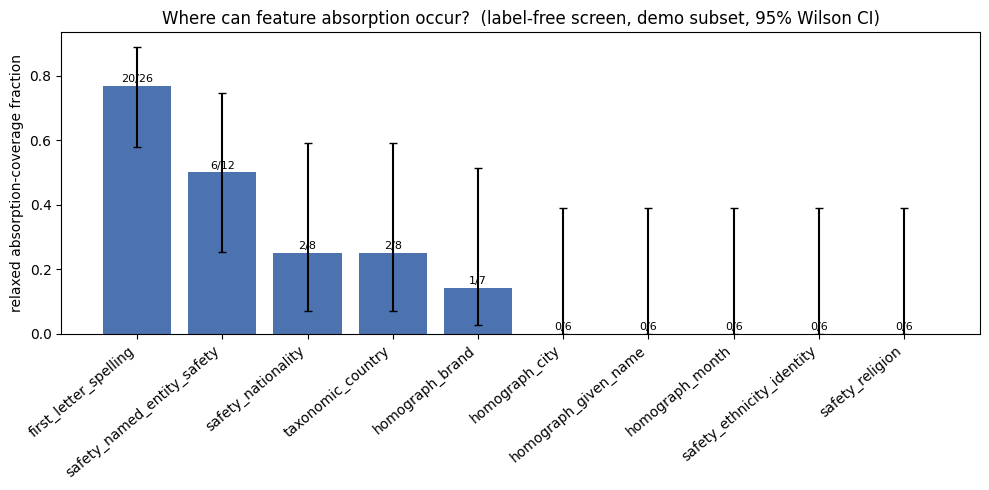

=== DEMO-SUBSET pooled coverage (recomputed in this notebook) ===
  strict : 6/46 = 0.130  Wilson[0.0612, 0.2567]
  relaxed: 31/91 = 0.341  Wilson[0.2515, 0.4427]

=== FULL-RUN headline (all 336 candidates / 110 eligible; published artifact) ===
  strict : 6/110 = 0.0545  Wilson[0.0252, 0.1139]
  relaxed: 31/336 = 0.0923  Wilson[0.0658, 0.128]

Takeaway: absorption is homograph- and NAMED-ENTITY-confined (Georgia; Amazon/Bush/Cook; spelling
word-types). Demographic religion/ethnicity and calendar months are NO_HOLE -> absorption need not
be feared there. The screen is $0 and label-free on ANY frozen SAE.


In [12]:
# ---- per-hierarchy relaxed coverage bar chart ----
rel = [t for t in coverage_table if t["gate"] == "relaxed" and t["hierarchy"] != "POOLED"]
rel = sorted(rel, key=lambda t: t["fraction"], reverse=True)
labels = [t["hierarchy"] for t in rel]
fracs  = [t["fraction"] for t in rel]
err_lo = [max(0.0, t["fraction"] - t["wilson_lo"]) for t in rel]
err_hi = [max(0.0, t["wilson_hi"] - t["fraction"]) for t in rel]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(labels)), fracs, yerr=[err_lo, err_hi], capsize=3, color="#4C72B0")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha="right")
ax.set_ylabel("relaxed absorption-coverage fraction")
ax.set_title("Where can feature absorption occur?  (label-free screen, demo subset, 95% Wilson CI)")
for i, t in enumerate(rel):
    ax.text(i, fracs[i] + 0.012, f"{t['n_structured']}/{t['N']}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

# ---- pooled headline: demo subset vs full-run published ----
pooled = {(t["hierarchy"], t["gate"]): t for t in coverage_table}
ps = pooled[("POOLED", "strict")]; pr = pooled[("POOLED", "relaxed")]
print("=== DEMO-SUBSET pooled coverage (recomputed in this notebook) ===")
print(f"  strict : {ps['n_structured']}/{ps['N']} = {ps['fraction']:.3f}  Wilson[{ps['wilson_lo']}, {ps['wilson_hi']}]")
print(f"  relaxed: {pr['n_structured']}/{pr['N']} = {pr['fraction']:.3f}  Wilson[{pr['wilson_lo']}, {pr['wilson_hi']}]")
print()
hl = data["full_run_coverage_headline"]
print("=== FULL-RUN headline (all 336 candidates / 110 eligible; published artifact) ===")
print(f"  strict : {hl['pooled_strict_n']} = {hl['pooled_strict_fraction']}  Wilson{hl['pooled_strict_ci_wilson']}")
print(f"  relaxed: {hl['pooled_relaxed_n']} = {hl['pooled_relaxed_fraction']}  Wilson{hl['pooled_relaxed_ci_wilson']}")
print()
print("Takeaway: absorption is homograph- and NAMED-ENTITY-confined (Georgia; Amazon/Bush/Cook; spelling")
print("word-types). Demographic religion/ethnicity and calendar months are NO_HOLE -> absorption need not")
print("be feared there. The screen is $0 and label-free on ANY frozen SAE.")